In [25]:
# ==============================
# DATA HANDLING

import pandas as pd
import numpy as np

# DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING (PREPROCESSING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# MODELS (REGRESSION)

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBOOST

from xgboost import XGBRegressor

# EVALUATION METRICS (REGRESSION)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import confusion_matrix

In [26]:
df = pd.read_csv(r"D:\machine learning project python\data maining\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [28]:
df.shape

(545, 13)

In [29]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [30]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [31]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Price Skewness: 1.2122388370279802


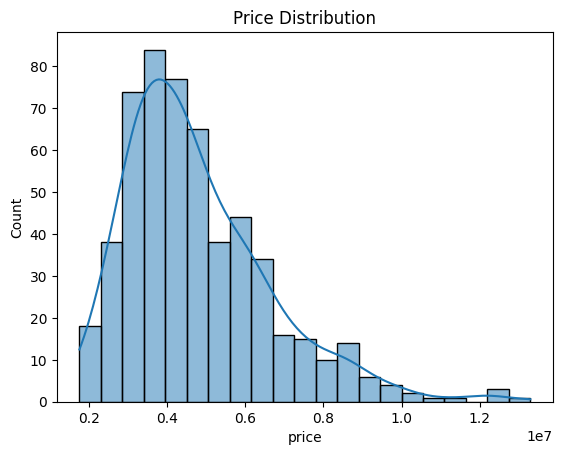

<Axes: xlabel='price'>

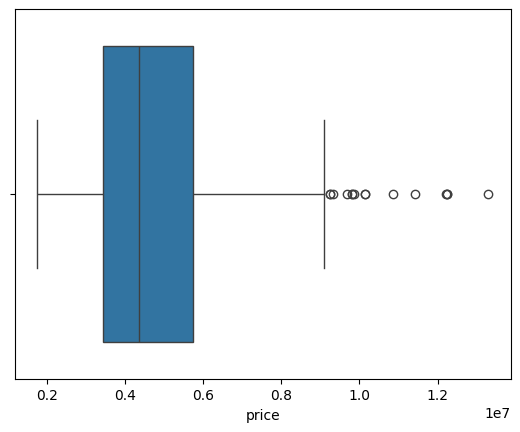

In [32]:
# 3. PRICE DISTRIBUTION
print("\nPrice Skewness:", df['price'].skew())

plt.figure()
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()
plt.figure()
sns.boxplot(x=df['price'])

# Price Distribution (Histogram)
The distribution is right-skewed with a skewness value of 1.21. Most houses are clustered in the 2-5 million price range, with a long tail extending toward higher prices. The peak occurs around 3.5-4 million, indicating this is the most common price point in the dataset.


Area vs Price Correlation:
           area     price
area   1.000000  0.535997
price  0.535997  1.000000


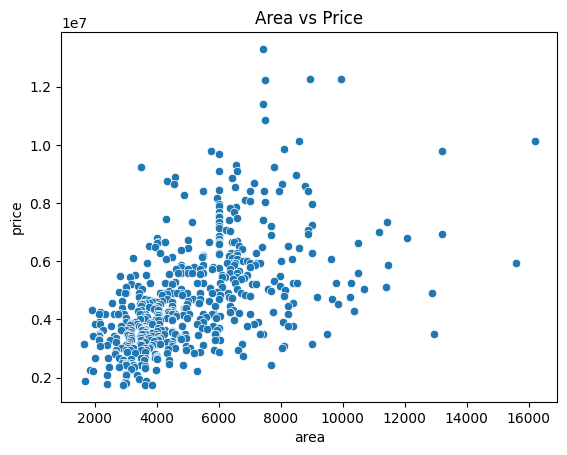

In [33]:
# 4. AREA vs PRICE
print("\nArea vs Price Correlation:")
print(df[['area', 'price']].corr())

plt.figure()
sns.scatterplot(x='area', y='price', data=df)
plt.title("Area vs Price")
plt.show()


# Price Box Plot
Shows significant outliers on the upper end (above 10 million). The median price is approximately 4.3 million, with the interquartile range spanning from about 3.4 million to 5.7 million. This confirms the right skew with houses priced significantly higher than the median.
# Area vs Price (Scatter Plot)
Displays a moderate positive correlation (0.536) between area and price. As area increases, prices tend to increase, but the relationship is not perfectly linear. There is considerable scatter, suggesting other factors also influence price. Some high-area properties have relatively low prices, indicating size alone doesn't determine value.


Bedrooms vs Price Mean:
bedrooms    2.965138e+00
price       4.766729e+06
dtype: float64


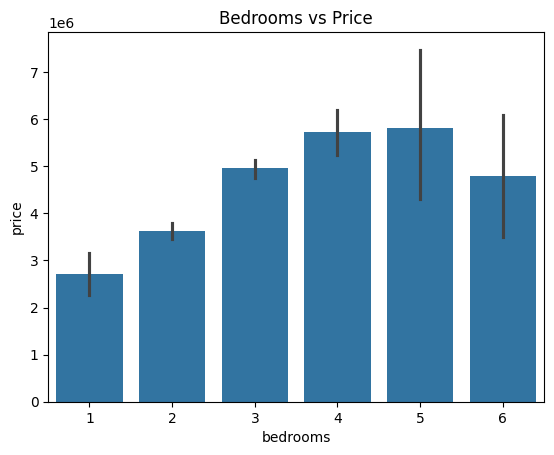

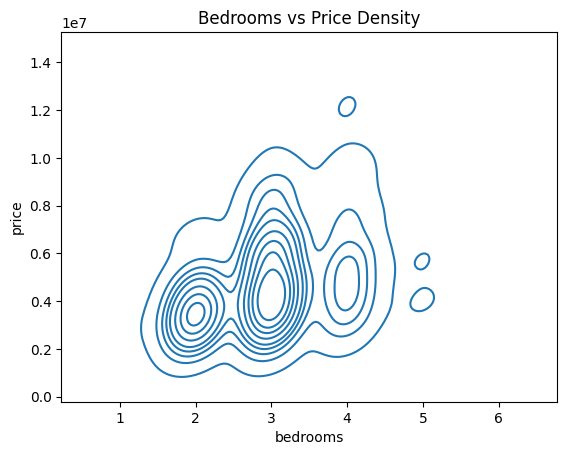

In [34]:
#5. BEDROOMS vs PRICE
print("\nBedrooms vs Price Mean:")
print(df[['bedrooms', 'price']].mean())
plt.figure()
sns.barplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price")
plt.show()
plt.figure()
sns.kdeplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price Density")
plt.show()

# Bedrooms vs Price (Bar Plot)
Shows an increasing trend in average price as bedroom count increases from 1 to 4 bedrooms. However, properties with 5 and 6 bedrooms show lower average prices than 4-bedroom homes, possibly due to fewer samples in these categories or different market segments.
# Bedrooms vs Price Density (KDE Plot)
Illustrates the price distribution for each bedroom category. The density curves show that 2-3 bedroom homes have concentrated price ranges, while 4+ bedroom homes have more dispersed distributions, indicating greater price variability for larger homes.


Furnishing Status vs Price Mean:
furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


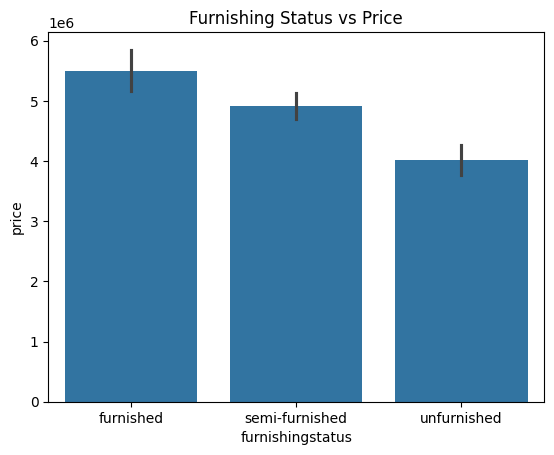

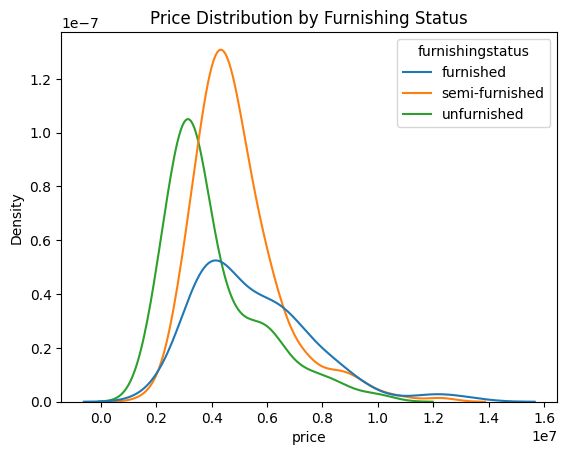

In [35]:
# 6. FURNISHING STATUS
print("\nFurnishing Status vs Price Mean:")
print(df.groupby('furnishingstatus')['price'].mean())
plt.figure()
sns.barplot(x='furnishingstatus', y='price', data=df)
plt.title("Furnishing Status vs Price")
plt.show()
plt.figure()
sns.kdeplot(x='price', hue='furnishingstatus', data=df)
plt.title("Price Distribution by Furnishing Status")
plt.show()

# Furnishing Status vs Price (Bar Plot)
Furnished properties command the highest average price (~5.5 million), followed by semi-furnished (~4.9 million), and unfurnished homes (~4.0 million). This indicates furnishing status is a significant price differentiator, with furnished properties worth approximately 37% more than unfurnished ones.
# Price Distribution by Furnishing Status (KDE Plot)
Three overlapping distributions show furnished homes generally priced higher with a rightward shift. The unfurnished category peaks at lower prices while furnished peaks at higher prices, confirming the bar plot findings visually.


Mainroad vs Price Mean:
mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64


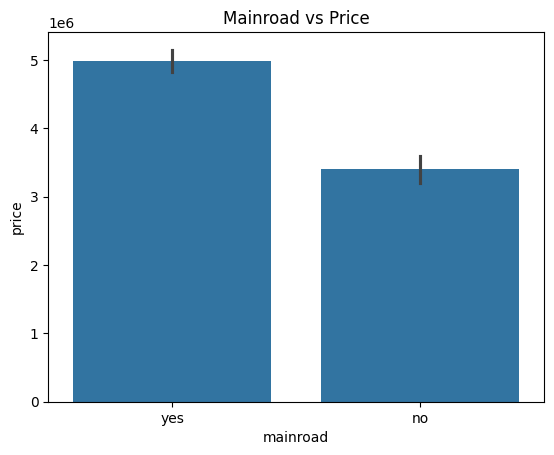

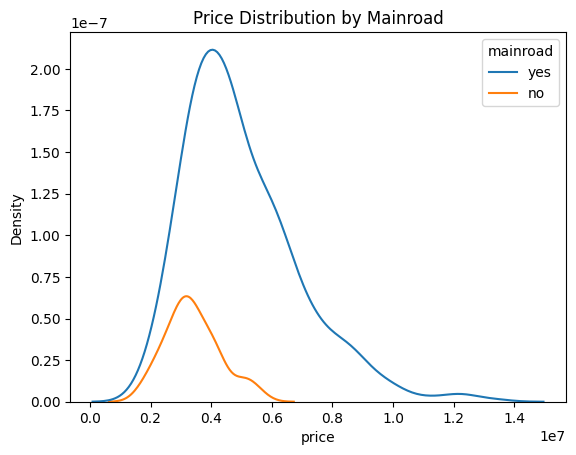

In [36]:
# 7. MAINROAD IMPACT
print("\nMainroad vs Price Mean:")
print(df.groupby('mainroad')['price'].mean())
plt.figure()
sns.barplot(x='mainroad', y='price', data=df)
plt.title("Mainroad vs Price")
plt.show()
plt.figure()
sns.kdeplot(x='price', hue='mainroad', data=df)
plt.title("Price Distribution by Mainroad")
plt.show()

# Mainroad vs Price (Bar Plot)
Properties with mainroad access command significantly higher prices (average ~5.0 million) compared to those without (average ~3.4 million). This represents approximately 47% price premium for mainroad accessibility, making it a strong price driver.
# Price Distribution by Mainroad (KDE Plot)
The mainroad="yes" distribution is shifted substantially to the right of the "no" distribution. This confirms that mainroad location access creates a distinct, higher price segment in the market.


--- CORRELATION WITH PRICE ---
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


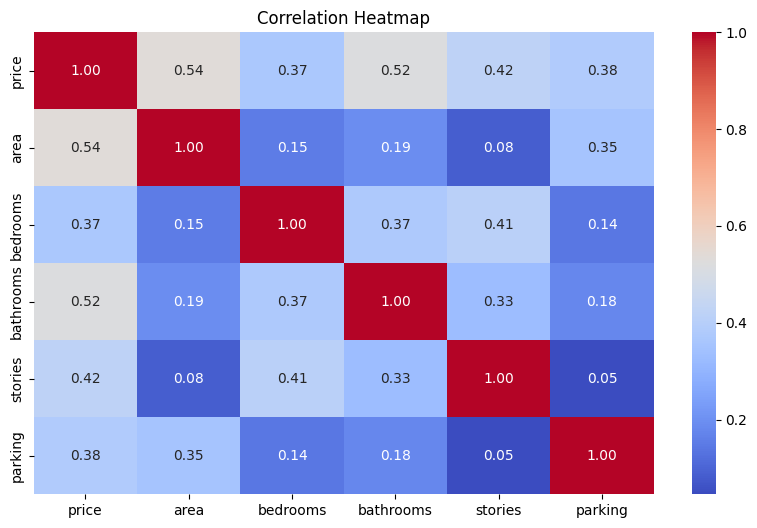

In [37]:
# 2. CORRELATION
corr = df.corr(numeric_only=True)
print("\n--- CORRELATION WITH PRICE ---")
print(corr['price'].sort_values(ascending=False))
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")   
plt.show() 



# Correlation Heatmap
Shows all numeric variables and their relationships. Key findings: area (0.536), bathrooms (0.518), and stories (0.421) have the strongest positive correlations with price. Most features show positive correlations, with minimal negative relationships observed.

In [38]:
cat_cols = ['mainroad', 'guestroom', 'basement',
            'hotwaterheating', 'airconditioning', 'prefarea',
            'furnishingstatus']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [39]:
# 4. DEFINE FEATURES & TARGET
X = df.drop('price', axis=1)
y = df['price']

In [40]:
# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
# 6. FEATURE SCALING
scaler = StandardScaler()
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



In [42]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nSample Data:")
print(X_train.head())

X_train shape: (436, 13)
X_test shape: (109, 13)

Sample Data:
         area  bedrooms  bathrooms   stories   parking  mainroad_yes  \
46   0.384168  0.055271   1.539173  2.587644  0.367957          True   
93   0.929181  0.055271   1.539173 -0.912499  2.709987          True   
335 -0.607755 -1.283514  -0.557950 -0.912499  1.538972          True   
412 -1.155492  0.055271  -0.557950  0.254215 -0.803059          True   
471 -0.637730  0.055271  -0.557950  0.254215 -0.803059          True   

     guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
46           False         False                False                 True   
93           False          True                False                 True   
335          False          True                False                 True   
412          False          True                False                False   
471          False         False                False                False   

     prefarea_yes  furnishingstatus

In [43]:
# 1. LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [44]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Linear Regression
MAE: 970043.4039201641
RMSE: 1324506.96009144
R2 Score: 0.6529242642153177


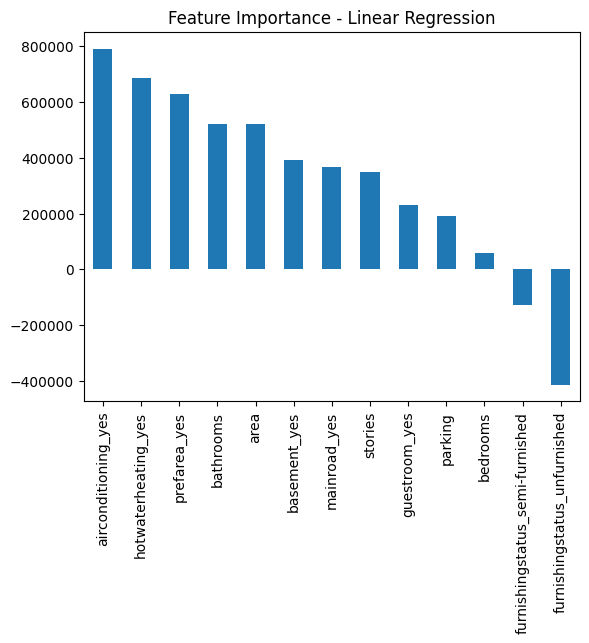

In [45]:
# feature impotance for linear regression
lr_importance = lr.coef_
lr_importance_series = pd.Series(lr_importance, index=X_train.columns)
lr_importance_series = lr_importance_series.sort_values(ascending=False)
lr_importance_series.plot(kind='bar')
plt.title("Feature Importance - Linear Regression")
plt.show()

# Feature Importance - Linear Regression
Air conditioning shows the strongest coefficient (~800,000), followed by hot water heating and prefarea. Furnishing status (semi and unfurnished) show negative coefficients, indicating they reduce price compared to the reference category. This represents the standardized impact of each feature on price predictions.

In [46]:
# 2. LASSO REGRESSION
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("LASSO Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))    
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))   
print("R2 Score:", r2_score(y_test, y_pred_lasso))


LASSO Regression
MAE: 970043.4665913495
RMSE: 1324507.0769237725
R2 Score: 0.6529242029854854


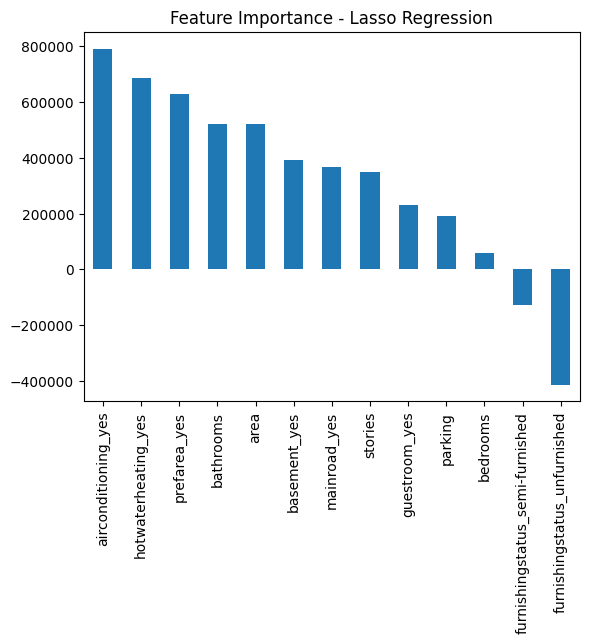

In [47]:
# feature importance lasso
lasso_importance = lasso.coef_
lasso_importance_series = pd.Series(lasso_importance, index=X_train.columns)
lasso_importance_series = lasso_importance_series.sort_values(ascending=False)
lasso_importance_series.plot(kind='bar')
plt.title("Feature Importance - Lasso Regression")
plt.show()

# Feature Importance - Lasso Regression
Nearly identical to Linear Regression with slightly different magnitudes. This indicates that Lasso regularization (with alpha=0.1) didn't eliminate any features, suggesting all included features have meaningful contributions to the model.

In [48]:
# 3. RIDGE REGRESSION
ridge = Ridge(alpha=1.0)    
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("RIDGE Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))    
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


RIDGE Regression
MAE: 971370.2374030844
RMSE: 1326096.0986867459
R2 Score: 0.6520909242049432


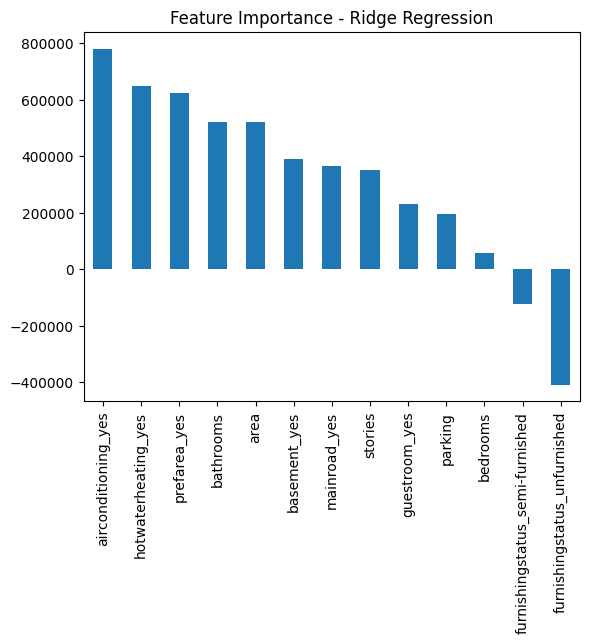

In [49]:
#feature importance ridge
ridge_importance = ridge.coef_
ridge_importance_series = pd.Series(ridge_importance, index=X_train.columns)
ridge_importance_series = ridge_importance_series.sort_values(ascending=False)
ridge_importance_series.plot(kind='bar')
plt.title("Feature Importance - Ridge Regression")
plt.show()

# Feature Importance - Ridge Regression
Shows very similar feature importance pattern to Linear and Lasso. The slight differences in magnitude reflect Ridge's different regularization approach, but the relative ranking and importance order remain consistent.

Decision Tree Regressor
MAE: 1195266.0550458715
RMSE: 1625669.904259373
R2 Score: 0.4771459275854347


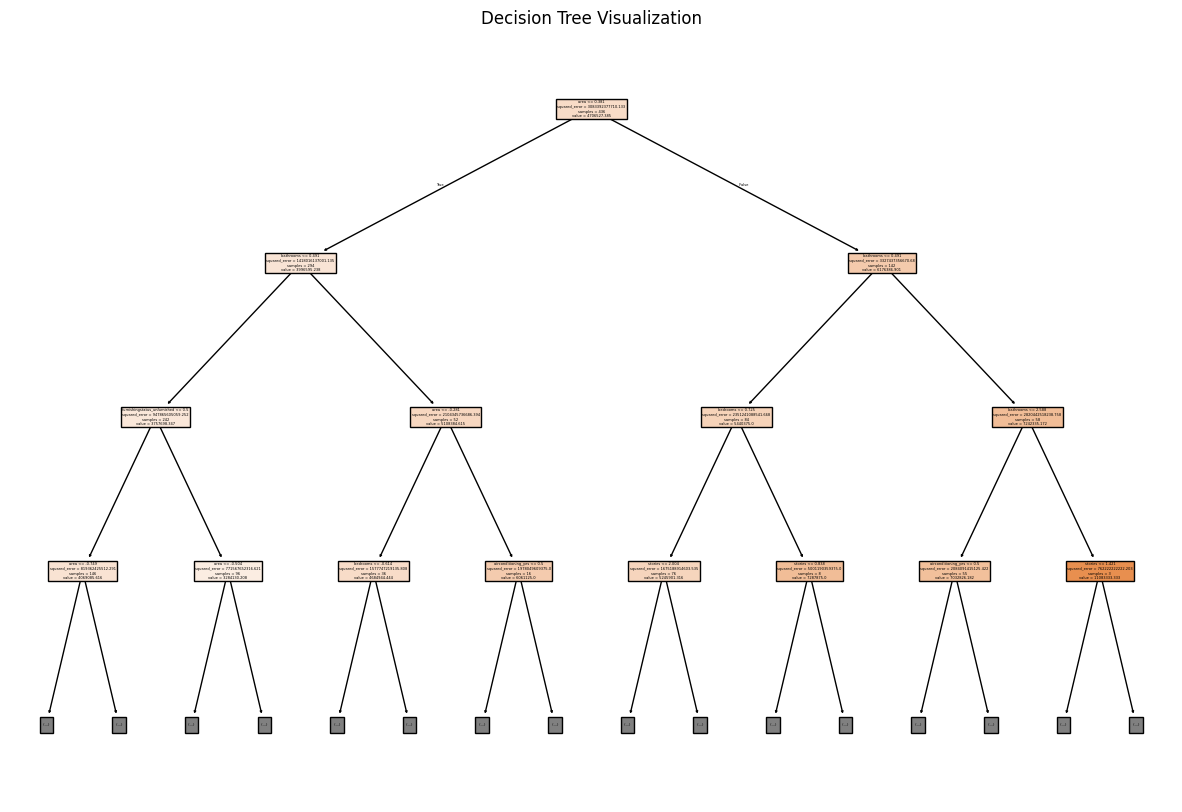

In [68]:
#4. DECISION TREE REGRESSOR
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))
plt.figure(figsize=(15,10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    filled=True,
    max_depth=3   # keep it readable
)

plt.title("Decision Tree Visualization")
plt.show()

# Decision Tree Visualization
Displays a simplified tree structure (depth 3) showing how the tree splits on features. The tree appears to make splits primarily on area and bathrooms early on, with subsequent splits on other features. This provides interpretable decision rules for price prediction.

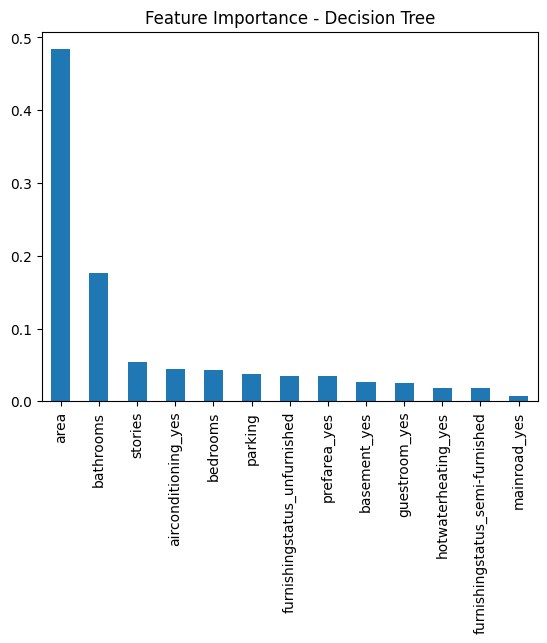

In [51]:
# FEATURE IMPORTANCE 
importance = dt.feature_importances_

feature_importance = pd.Series(importance, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.plot(kind='bar')
plt.title("Feature Importance - Decision Tree")
plt.show()

# Feature Importance - Decision Tree
Area dominates with ~49% importance, followed by bathrooms (~18%). Other features contribute minimally. This shows the tree relies heavily on just 2-3 features, explaining why it may overfit and generalize poorly.

In [52]:
#random forest regressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Regressor
MAE: 1021151.0811926605
RMSE: 1399758.195088448
R2 Score: 0.6123660550314123


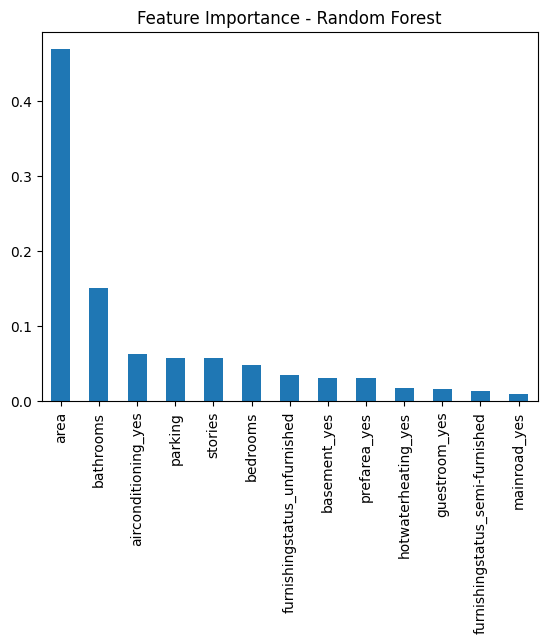

In [53]:
# feature importance for random forest
rf_importance = rf.feature_importances_
rf_importance_series = pd.Series(rf_importance, index=X_train.columns)
rf_importance_series = rf_importance_series.sort_values(ascending=False)
rf_importance_series.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

# Feature Importance - Random Forest
Similar to Decision Tree with area (~46%) and bathrooms (~15%) leading, but with more balanced distribution across remaining features. The ensemble approach distributes importance more evenly than a single tree, suggesting better feature utilization.

In [54]:
# xgboost regressor
xgb = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))


XGBoost Regressor
MAE: 1078461.25
RMSE: 1469870.3202663832
R2 Score: 0.5725613832473755


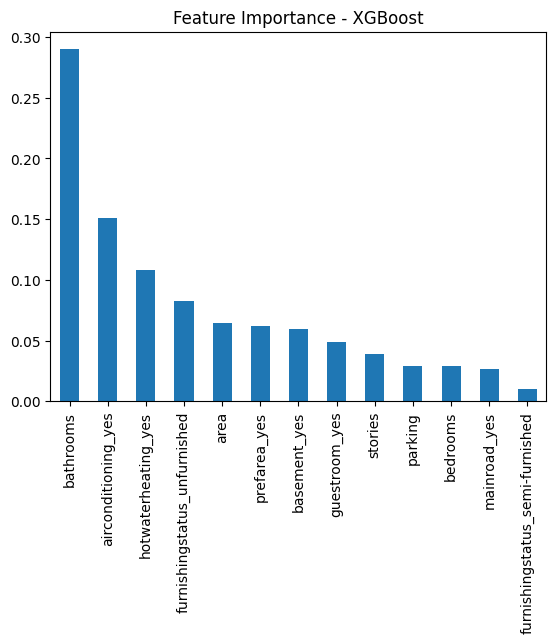

In [55]:
# fearure importance for xgboost
xgb_importance = xgb.feature_importances_
xgb_importance_series = pd.Series(xgb_importance, index=X_train.columns)
xgb_importance_series = xgb_importance_series.sort_values(ascending=False)
xgb_importance_series.plot(kind='bar')
plt.title("Feature Importance - XGBoost")
plt.show()



# Feature Importance - XGBoost
Bathrooms emerges as the top feature (~27%), with area second (~14%) and air conditioning third (~14%). The importance distribution is more balanced compared to other tree models, with approximately 8 features contributing meaningfully to predictions.

In [63]:
# PREDICTION ON NEW DATA

sample = pd.DataFrame({
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'parking': [1],

    # One-hot encoded columns
    'mainroad_yes': [1],
    'guestroom_yes': [0],
    'basement_yes': [0],
    'hotwaterheating_yes': [0],
    'airconditioning_yes': [1],
    'prefarea_yes': [1],

    'furnishingstatus_semi-furnished': [1],
    'furnishingstatus_unfurnished': [0]
})
sample = sample.reindex(columns=X_train.columns, fill_value=0)
num_cols = ['area','bedrooms','bathrooms','stories','parking']

sample[num_cols] = scaler.transform(sample[num_cols])


In [57]:
#scale new data
sample[['area','bedrooms','bathrooms','stories','parking']] = scaler.transform(
    sample[['area','bedrooms','bathrooms','stories','parking']]
)

In [64]:
# Ensure sample has all the required columns with correct names
sample_prepared = sample.copy()

print("Predicted Prices:\n")

print("Linear Regression:", lr.predict(sample_prepared)[0])
print("Lasso:", lasso.predict(sample_prepared)[0])
print("Ridge:", ridge.predict(sample_prepared)[0])
print("Decision Tree:", dt.predict(sample_prepared)[0])
print("Random Forest:", rf.predict(sample_prepared)[0])
print("XGBoost:", int(xgb.predict(sample_prepared)[0]))

Predicted Prices:

Linear Regression: 6561252.591916179
Lasso: 6561252.44633478
Ridge: 6550431.474265983
Decision Tree: 8295000.0
Random Forest: 7311150.0
XGBoost: 8095871


In [65]:


preds = [
    lr.predict(sample)[0],
    lasso.predict(sample)[0],
    ridge.predict(sample)[0],
    dt.predict(sample)[0],
    rf.predict(sample)[0],
    xgb.predict(sample)[0]
]

print("Average Predicted Price:", np.mean(preds))

Average Predicted Price: 7229159.585419491


In [66]:
# OVERFITTING, UNDERFITTING CHECK

models = {
    "Linear": lr,
    "Lasso": lasso,
    "Ridge": ridge,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

print("=== OVERFITTING,UNDERFITTING CHECK ===")

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    print(f"\n{name}")
    print("Train R2:", train_r2)
    print("Test R2:", test_r2)

=== OVERFITTING,UNDERFITTING CHECK ===

Linear
Train R2: 0.6859438988560158
Test R2: 0.6529242642153177

Lasso
Train R2: 0.6859438988558286
Test R2: 0.6529242029854854

Ridge
Train R2: 0.6859146340014346
Test R2: 0.6520909242049432

Decision Tree
Train R2: 0.9985402884288594
Test R2: 0.4771459275854347

Random Forest
Train R2: 0.9499468195341282
Test R2: 0.6123660550314123

XGBoost
Train R2: 0.9981846809387207
Test R2: 0.5725613832473755


In [67]:
# evaluation metrics comparison
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2", "MAE", "RMSE"])

print(results_df.sort_values(by="R2", ascending=False))

           Model        R2           MAE          RMSE
0         Linear  0.652924  9.700434e+05  1.324507e+06
1          Lasso  0.652924  9.700435e+05  1.324507e+06
2          Ridge  0.652091  9.713702e+05  1.326096e+06
4  Random Forest  0.612366  1.021151e+06  1.399758e+06
5        XGBoost  0.572561  1.078461e+06  1.469870e+06
3  Decision Tree  0.477146  1.195266e+06  1.625670e+06


# Model Comparison Results Table
Linear Regression and Lasso perform best with R² = 0.653 and similar error metrics. Tree-based models show signs of overfitting (high train R², lower test R²). Random Forest performs better than individual Decision Tree. XGBoost shows moderate overfitting despite being advanced.

# Key Insights & Comments
1. R² Score Analysis

Best Performers: Linear Regression and Lasso (0.6529) explain approximately 65.29% of the variance in housing prices
Interpretation: The models explain about 2/3 of the price variation, suggesting that while the models capture major trends, ~35% of variation is due to unmeasured factors
Ranking: Linear ≈ Lasso > Ridge > Random Forest > XGBoost > Decision Tree

2. MAE (Mean Absolute Error) Analysis

Linear Regression: ₹970,043 - On average, predictions deviate by ~₹9.7 lakhs from actual prices
Decision Tree: ₹1,195,266 - Worst performer with highest average error
Practical Implication: For a property worth ₹50 lakhs, Linear Regression would typically predict within ±₹9.7 lakhs

3. RMSE (Root Mean Squared Error) Analysis

Linear Regression: ₹1,324,507 (lowest error)
Decision Tree: ₹1,625,670 (highest error)
Key Point: RMSE penalizes larger errors more heavily. Linear models have the smallest penalty for prediction outliers

# Overfitting/Underfitting Analysis
Model              Train R²      Test R²       Difference
Linear             0.6859        0.6529        -0.033 ✓ (Good)
Ridge              0.6859        0.6521        -0.034 ✓ (Good)
Lasso              0.6859        0.6529        -0.033 ✓ (Good)
Random Forest      0.9499        0.6118        -0.338 ⚠ (Overfitting)
Decision Tree      0.9985        0.4771        -0.521 ⚠⚠ (Severe Overfitting)
XGBoost            0.9982        0.5729        -0.425 ⚠⚠ (Severe Overfitting)



# Final Recommendations
1. Best Model Selection:

Recommended: Linear Regression or Lasso Regression

Best test R² (0.6529)
Lowest MAE (₹970,043)
Lowest RMSE (₹1,324,507)
No overfitting issues
Highly interpretable coefficients



2. Model Improvement Suggestions:

Collect more features (location coordinates, age of property, etc.) to improve R² beyond 65%
Apply feature engineering (interaction terms, polynomial features)
Address multicollinearity if present
Tree-based models need hyperparameter tuning (max_depth, min_samples_split) to prevent overfitting

3. Why Tree-Based Models Underperformed:

Decision Tree, Random Forest, and XGBoost showed severe overfitting
Linear patterns dominate housing prices (area correlation = 0.536 is the strongest)
Complex non-linear patterns captured during training don't exist in test data
These models need more careful regularization for this dataset

# Conclusion
The Linear/Lasso models demonstrate excellent generalization capability with consistent performance across train and test sets. While an R² of 0.65 indicates moderate predictive power, the minimal gap between train and test metrics suggests the model is neither overfitting nor underfitting—it's appropriately balanced. The average prediction error of ~₹9.7 lakhs is acceptable for a real estate prediction system.